<a href="https://colab.research.google.com/github/Aslan934/InstaCart_orders_analysis_pandas/blob/main/instacart_orders_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploring and Cleaning Data with Pandas: Instacart Project**
# Data Dictionary

There are **five tables** in the dataset. All of them will be used during **data preprocessing** and **exploratory data analysis (EDA)**.

---

## 1. `instacart_orders.csv`

Each row corresponds to one order placed through the Instacart app.

| Column                   | Description                                                                          |
| ------------------------ | ------------------------------------------------------------------------------------ |
| `order_id`               | Unique ID for each order                                                             |
| `user_id`                | Unique ID for each customer account                                                  |
| `order_number`           | Number of times the customer has placed an order                                     |
| `order_dow`              | Day of the week the order was placed (`0` represents an unspecified day of the week) |
| `order_hour_of_day`      | Hour of the day when the order was placed                                            |
| `days_since_prior_order` | Number of days since the customer's previous order                                   |

---

## 2. `products.csv`

Each row corresponds to a unique product available for purchase.

| Column          | Description                                   |
| --------------- | --------------------------------------------- |
| `product_id`    | Unique ID for each product                    |
| `product_name`  | Name of the product                           |
| `aisle_id`      | Unique ID for the grocery aisle category      |
| `department_id` | Unique ID for the grocery department category |

---

## 3. `order_products.csv`

Each row corresponds to one product included in an order.

| Column              | Description                                                                 |
| ------------------- | --------------------------------------------------------------------------- |
| `order_id`          | Unique ID for each order                                                    |
| `product_id`        | Unique ID for each product                                                  |
| `add_to_cart_order` | The sequential order in which the item was added to the cart                |
| `reordered`         | `0` if the customer has never ordered this product before; `1` if they have |

---

## 4. `aisles.csv`

Contains information about grocery aisle categories.

| Column     | Description                               |
| ---------- | ----------------------------------------- |
| `aisle_id` | Unique ID for each grocery aisle category |
| `aisle`    | Name of the aisle                         |

---

## 5. `departments.csv`

Contains information about grocery department categories.

| Column          | Description                                    |
| --------------- | ---------------------------------------------- |
| `department_id` | Unique ID for each grocery department category |
| `department`    | Name of the department                         |


### Importing Data

In [26]:
import pandas as pd

In [27]:
orders         = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pandas Project 1/datasets/instacart_orders.csv', sep=';')
products       = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pandas Project 1/datasets/products.csv', sep=';')
departments    = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pandas Project 1/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pandas Project 1/datasets/aisles.csv', sep=';')
order_products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pandas Project 1/datasets/order_products.csv', sep=';')

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## First look and Data cleaning
---

### `orders` data frame

In [29]:
# Checking columns
orders.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [30]:
# Checking random 5 rows to see if data types are proper
orders.sample(5)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
365448,70200,70067,1,2,15,NaN
446776,39325,55,8,2,18,30.0
154416,2073386,105052,31,6,18,7.0
52883,425794,86376,24,4,14,7.0
225894,2051660,162097,21,0,10,10.0


In [31]:
# Check for duplicated orders
orders[orders["order_id"].duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


In [32]:
# Double check for duplicate rows, there are 15 duplicates total
orders.duplicated().sum()

np.int64(15)

In [33]:
# Check for all orders placed Wednesday at 2:00 AM
orders[(orders["order_dow"]==3) & (orders['order_hour_of_day']==2)].duplicated().sum()

np.int64(15)

In [34]:
# Remove duplicate orders
orders.drop_duplicates(inplace=True)

In [35]:
# Double check for duplicate order IDs only
orders[orders["order_id"].duplicated()].sum()

,0
order_id,0.0
user_id,0.0
order_number,0.0
order_dow,0.0
order_hour_of_day,0.0
days_since_prior_order,0.0


### `products` data frame

In [36]:
# Checking columns info
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [37]:
# Checking 5 random rows to see if fields have peroper data types
products.sample(5)

,product_id,product_name,aisle_id,department_id
6344,6345,Gray Salt Caramels in Dark Chocolate,45,19
23626,23627,Isaac Mizrahi 2-Ply White Facial Tissues,54,17
16219,16220,Cream Soda,77,7
6859,6860,Organic Balsamic Vinaigrette,89,13
34893,34894,Kids Cavity Protection Sparkle Fun Flavor Toot...,20,11


In [38]:
# Checking for fully duplicate rows, there are no any duplocates
products.duplicated().sum()

np.int64(0)

In [39]:
# Checking for just duplicate product IDs
products['product_id'].duplicated().sum()

np.int64(0)

In [40]:
# Checking for just duplicate product names
products['product_name'].str.lower().duplicated().sum()

np.int64(1361)

In [41]:
#Checking for duplicate product names that aren't missing
products[products['product_name'].notna()]['product_name'].duplicated().sum()

np.int64(0)

### `departments` data frame

In [42]:
# Checking columns

departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [43]:
# Checking 5 random rows
departments.sample(5)

,department_id,department
10,11,personal care
7,8,pets
14,15,canned goods
18,19,snacks
5,6,international


In [44]:
# Checking duplicates for all rows and columns
departments.duplicated().sum()


np.int64(0)

In [45]:
# Checking duplicates for department id
departments['department_id'].duplicated().sum()


np.int64(0)

In [46]:
# Checking duplicates for department names
departments['department'].duplicated().sum()


np.int64(0)

In [47]:
# Checking unique deparment names
departments['department'].unique()

array(['frozen', 'other', 'bakery', 'produce', 'alcohol', 'international',
       'beverages', 'pets', 'dry goods pasta', 'bulk', 'personal care',
       'meat seafood', 'pantry', 'breakfast', 'canned goods',
       'dairy eggs', 'household', 'babies', 'snacks', 'deli', 'missing'],
      dtype=object)

### `aisles` data frame

In [48]:
# Checking columns

aisles.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [49]:
# Checking 5 random samples

aisles.sample(5)

,aisle_id,aisle
30,31,refrigerated
58,59,canned meals beans
4,5,marinades meat preparation
112,113,frozen juice
42,43,buns rolls


In [50]:
# checking duplicated for all rows and columns

aisles.duplicated().sum()

np.int64(0)

In [51]:
# checking duplicated seperate for id and aisle name
aisles['aisle_id'].duplicated().sum()
aisles['aisle'].duplicated().sum()

np.int64(0)

In [52]:
# Checking unique aisle names
aisles['aisle'].unique()

array(['prepared soups salads', 'specialty cheeses',
       'energy granola bars', 'instant foods',
       'marinades meat preparation', 'other', 'packaged meat',
       'bakery desserts', 'pasta sauce', 'kitchen supplies',
       'cold flu allergy', 'fresh pasta', 'prepared meals',
       'tofu meat alternatives', 'packaged seafood', 'fresh herbs',
       'baking ingredients', 'bulk dried fruits vegetables',
       'oils vinegars', 'oral hygiene', 'packaged cheese', 'hair care',
       'popcorn jerky', 'fresh fruits', 'soap', 'coffee', 'beers coolers',
       'red wines', 'honeys syrups nectars', 'latino foods',
       'refrigerated', 'packaged produce', 'kosher foods',
       'frozen meat seafood', 'poultry counter', 'butter',
       'ice cream ice', 'frozen meals', 'seafood counter',
       'dog food care', 'cat food care', 'frozen vegan vegetarian',
       'buns rolls', 'eye ear care', 'candy chocolate', 'mint gum',
       'vitamins supplements', 'breakfast bars pastries',
       '

### `order_products` data frame

In [53]:
# Check for fully duplicate rows
order_products.duplicated().sum()

np.int64(0)

In [54]:
# Double check for any other tricky duplicates (add_to_cart_order has null values)
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Find and remove missing values


### `products` data frame

In [55]:
# All missing product names are associated with aisle_id 100

print(products["product_name"].isna().sum())


products[products["product_name"].isna()]["aisle_id"].unique()

1258


array([100])

In [56]:
# All missing product names are associated with department ID 21

products[products["product_name"].isna()]["department_id"].unique()

array([21])

In [57]:
# These are missing aisle and departments
print(aisles[aisles["aisle_id"] == 100])
print(departments[departments["department_id"] == 21])

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


In [58]:
# Filling missing product names with 'Unknown'
products["product_name"]=products["product_name"].fillna('Unknown')

### `orders` data frame

In [59]:
# Are there any missing values where it's not a customer's first order? - Answer is no

orders[orders['order_number']!=1].isna().sum()

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,0


### `order_products` data frame

In [60]:
# What are the min and max values in this column?
print(order_products["add_to_cart_order"].max())
print(order_products["add_to_cart_order"].min())

64.0
1.0


In [61]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
missing_cart_orders=order_products.loc[order_products['add_to_cart_order'].isna(),'order_id']

missing_cart_orders

,order_id
737,2449164
9926,1968313
14394,2926893
16418,1717990
30114,1959075
...,...
4505662,1800005
4511400,1633337
4517562,404157
4534112,1673227


In [62]:
# Do all orders with missing values have more than 64 products? -- Answer is no


# Below are orders with at least one missing value

orders_with_missing_values = order_products[order_products.isna().any(axis=1)]

# then I wrote a query to find out if any value is bigger than 64
orders_with_missing_values.groupby("order_id")["product_id"].size().max()>64

False

In [63]:
# Replace missing values with 999 and convert column to integer type

order_products=order_products.fillna(999)

order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

order_products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


## Exploratory Data Analysis


In [64]:
# Checking if order_hour_of_day has values out of range (0,23)
# No values out of range
orders[~orders['order_hour_of_day'].between(0,23)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [65]:
# Checking if order_dow has values out of range (0,6)
# No values out of range
orders[~orders['order_dow'].between(0,6)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [66]:
# Here I found order count by hours, 10-15 is highest interval

orders["order_hour_of_day"].value_counts().head(5)

,count
order_hour_of_day,
10,40578
11,40032
15,39789
14,39631
13,39007


<Axes: title={'center': 'Orders by Time of Day'}, xlabel='Hour of Day', ylabel='Number of Orders'>

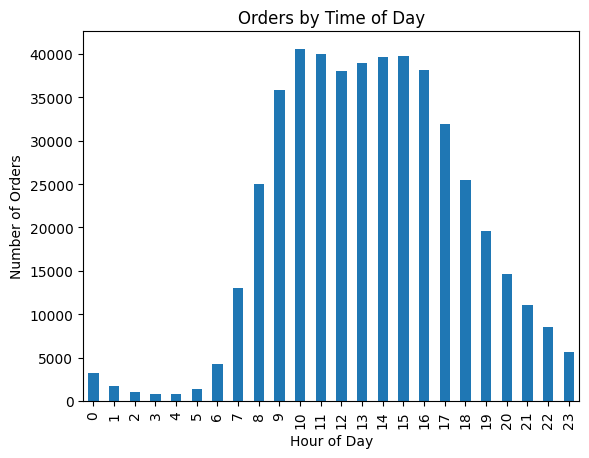

In [67]:
# Plot for order hours of day
orders["order_hour_of_day"].value_counts().sort_index().plot(
    kind="bar",
    xlabel="Hour of Day",
    ylabel="Number of Orders",
    title="Orders by Time of Day")

### [A3] What day of the week do people shop for groceries?

In [68]:
# Here I found order count by days, Monday, Tuesday, Wednesday have highest orders

orders["order_dow"].value_counts().head(3)

,count
order_dow,
0,84090
1,82185
2,65833


<Axes: title={'center': 'Orders by Day of Week'}, xlabel='Hour of Day', ylabel='Number of Orders'>

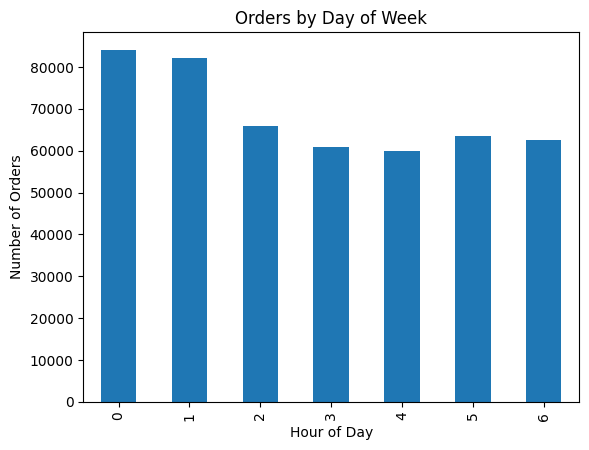

In [69]:
# Plot for order days of week
orders["order_dow"].value_counts().sort_index().plot(
    kind="bar",
    xlabel="Hour of Day",
    ylabel="Number of Orders",
    title="Orders by Day of Week")

In [70]:
# How long do people wait until placing another order? - I found average of days_since_prior_order - 11 days
orders['days_since_prior_order'].mean()

np.float64(11.101813900274362)

## Customer and Product Analysis


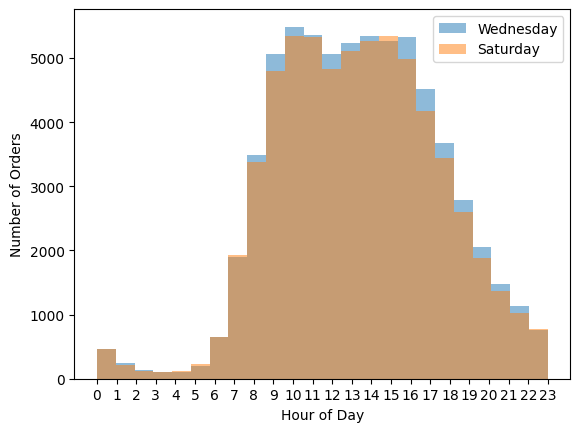

In [71]:
# Compared Wednesdays and Saturdays orders by hour frequencies, there is no major difference

import matplotlib.pyplot as plt
orders.loc[orders["order_dow"] == 2, "order_hour_of_day"].plot(
    kind="hist", bins=24, alpha=0.5, label="Wednesday"
)

orders.loc[orders["order_dow"] == 5, "order_hour_of_day"].plot(
    kind="hist", bins=24, alpha=0.5, label="Saturday"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.legend()

plt.xticks(range(0, 24, 1))
plt.show()

In [72]:
# Here I found distribution for the number of orders per customer
orders.groupby('user_id')['order_id'].count()

,order_id
user_id,
2,2
4,2
5,1
6,2
7,2
...,...
206203,1
206206,7
206207,5


In [73]:
# I want to find top 20 popular products
# first, i collect product id of top 20 sold products
top_20_sold_products = order_products.groupby('product_id')['order_id'].count().sort_values(ascending=False).head(20)

# then i display their name and id
products.loc[
    products["product_id"].isin(top_20_sold_products.index),
    ["product_id", "product_name"]
]

,product_id,product_name
5875,5876,Organic Lemon
8276,8277,Apple Honeycrisp Organic
13175,13176,Bag of Organic Bananas
16796,16797,Strawberries
21136,21137,Organic Strawberries
21902,21903,Organic Baby Spinach
22934,22935,Organic Yellow Onion
24851,24852,Banana
24963,24964,Organic Garlic
26208,26209,Limes


## Advanced Analysis

In [74]:
# How many items do people typically buy in one order
#I calculate the average number of products per order, anser is (10)

order_products.groupby('order_id')['product_id'].count().mean()


np.float64(10.098983215049127)

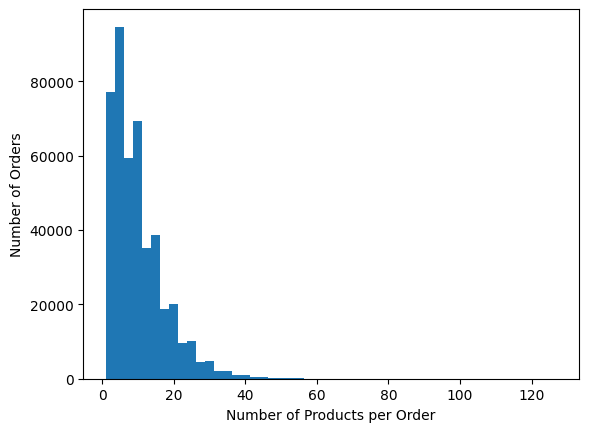

In [75]:
# distribution of number of products per order
order_products.groupby("order_id")["product_id"].count().plot(
    kind="hist",
    bins=50
)
plt.xlabel("Number of Products per Order")
plt.ylabel("Number of Orders")
plt.show()

In [76]:
# I want to find top 20 items that are reordered most frequently
# First I find top 20 reordered product id, by using filtering and groupby

top_20_reorderd_items=order_products[order_products['reordered']==1].groupby(
    'product_id')['reordered'].count().sort_values(ascending=False).head(20)


# then i display their name
products.loc[
    products["product_id"].isin(top_20_reorderd_items.index),
    ["product_id", "product_name"]
]


,product_id,product_name
5875,5876,Organic Lemon
8276,8277,Apple Honeycrisp Organic
13175,13176,Bag of Organic Bananas
16796,16797,Strawberries
21136,21137,Organic Strawberries
21902,21903,Organic Baby Spinach
22934,22935,Organic Yellow Onion
24851,24852,Banana
24963,24964,Organic Garlic
26208,26209,Limes


In [77]:
# For each product, what proportion of its orders are reorders
# Im finding mean value for each product, for example 0.80 means 80% of products were reorders.

order_products.groupby('product_id')['reordered'].mean()

,reordered
product_id,
1,0.564286
2,0.000000
3,0.738095
4,0.510204
7,0.500000
...,...
49690,0.800000
49691,0.430556
49692,0.416667


In [78]:
# For each customer, what proportion of their products ordered are reorders?
# First we merge 2 tables

merged_table = order_products.merge(orders[['order_id','user_id']], on='order_id')

# then we group by by user id and find average of reorders
reordered_products_proportion = merged_table.groupby('user_id')['reordered'].mean().reset_index()

reordered_products_proportion



,user_id,reordered
0,2,0.038462
1,4,0.000000
2,5,0.666667
3,6,0.000000
4,7,0.928571
...,...,...
149621,206203,0.222222
149622,206206,0.714286
149623,206207,0.891304
149624,206208,0.696000


In [79]:
# I want to find top 20 items that people put in their carts first
# First I found first added products on card

first_items=order_products[order_products['add_to_cart_order']==1]

# Then I used group by product, and count every time product was added as first order
first_items.groupby('product_id')['add_to_cart_order'].count().sort_values(ascending=False).head(20)

,add_to_cart_order
product_id,
24852,15562
13176,11026
27845,4363
21137,3946
47209,3390
21903,3336
47766,3044
19660,2336
16797,2308
